####  **Dogecoin Price Prediction using SARIMAX**

#### **1. Import Required Libraries**

In [ ]:
!pip install pmdarima
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore") # Suppress warnings from auto_arima

This block imports the libraries required for data analysis, visualization, and machine learning.

*   **Pandas** → Data manipulation and analysis.
*   **NumPy** → Numerical operations.
*   **Matplotlib** → Plotting graphs.
*   **Seaborn** → Advanced data visualization.
*   **RandomForestRegressor** → Machine learning model (imported but not used later).


**Result**: Libraries are loaded successfully and ready for use.


---



#### **2. Load Dataset**

In [ ]:
data = pd.read_csv("/content/DOGE-USD.csv")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


The Dogecoin historical price dataset is loaded from a CSV file. head() displays the first five records.


---



#### **3. Check Dataset Size**

In [ ]:
data.shape

(1761, 7)

Returns the number of rows and columns.
*  1761 observations (days)
*  7 features


---



#### **4. Correlation Analysis**

In [ ]:
data.corr(numeric_only=True)

# This code is modified by Susobhan Akhuli

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


Calculates correlation among numerical variables.

**Correlation values range from:**

*  +1 → Strong positive relationship
*  0 → No relationship
*  -1 → Strong negative relationship

**Key Observations:**

1.   **High vs Close**	0.995
2.   **Low vs Close**	0.994
2.   **Open vs Close**	0.992

This shows price-related variables are highly correlated.


---




#### **5. Correlation Heatmap**

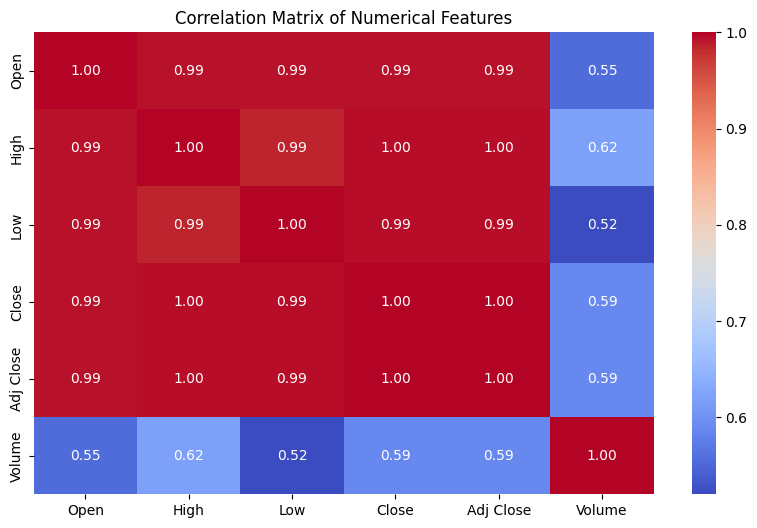

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Visualizes correlations using a heatmap.

**Result**
*  **Dark red** = strong positive correlation
*  **Blue** = weak correlation

**Insight**: Open, High, Low, and Close prices move together strongly.


---



#### **6. Convert Date Column & Missing Value Check**

In [ ]:
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)
data = data.dropna()
data.isnull().any()
data = data[data['Close'] > 0]

Converts Date into datetime format and sets it as the index. Removes missing values and checks whether any remain.

**Why?** Time-series models require a date index.


---



#### **7. Dataset Preview**

In [ ]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


#### **8. Count Missing Values**

In [ ]:
data.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
data = data.dropna()

#### **9. Statistical Summary**

In [ ]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


#### **10. Closing Price Trend**

Text(0.5, 1.0, 'Date vs Close of 2021')

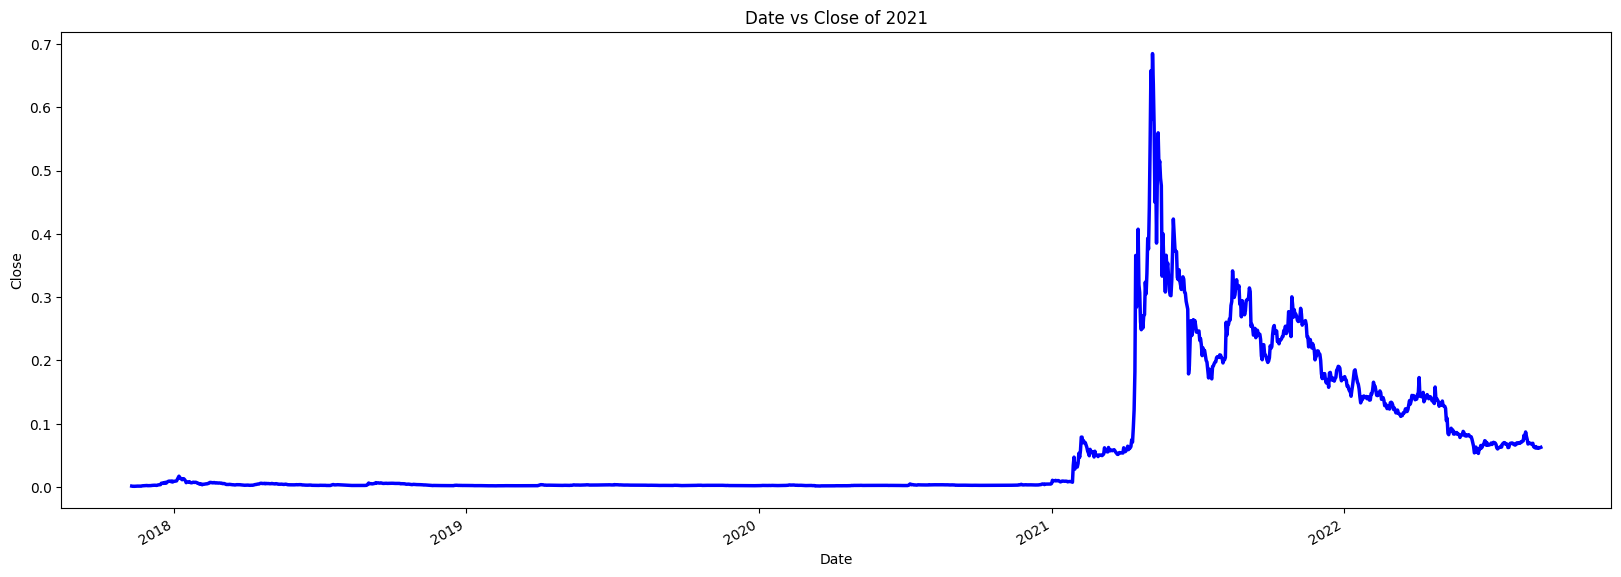

In [ ]:
plt.figure(figsize=(20, 7))
x = data.groupby('Date')['Close'].mean()
x.plot(linewidth=2.5, color='b')
plt.xlabel('Date')
plt.ylabel('Close')
plt.title("Date vs Close of 2021")

Plots Dogecoin closing prices over time.

**Result**: Shows long-term market trends and volatility.

**Insight**: Major spikes indicate periods of increased investor activity.


---



#### **11. High, Low and Close Prices**

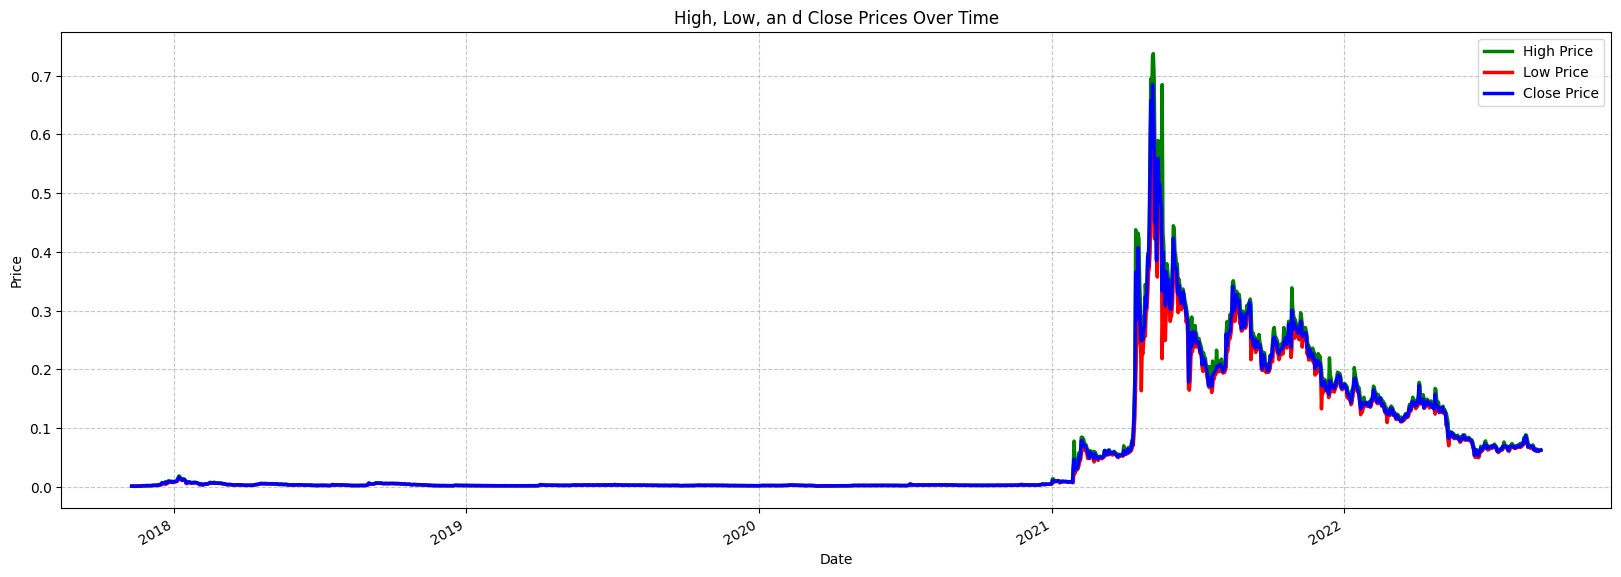

In [ ]:
plt.figure(figsize=(20, 7))

data['High'].plot(label='High Price', linewidth=2.5, color='green')
data['Low'].plot(label='Low Price', linewidth=2.5, color='red')
data['Close'].plot(label='Close Price', linewidth=2.5, color='blue')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title("High, Low, an d Close Prices Over Time")
plt.legend()
plt.grid(True, linestyle='--',alpha=.7)
plt.show()

**Compares**:

*  Highest daily price
*  Lowest daily price
*  Closing price

**Result**: Shows how Dogecoin fluctuates daily.


---



#### **12. Feature Engineering**

In [ ]:
data["gap"] = (data["High"] - data["Low"]) * data["Volume"]
data["y"] = data["High"] / data["Volume"]
data["z"] = data["Low"] / data["Volume"]
data["a"] = data["High"] / data["Low"]
data["b"] = (data["High"] / data["Low"]) * data["Volume"]
abs(data.corr()["Close"].sort_values(ascending=False))

,Close
Close,1.000000
Adj Close,1.000000
High,0.995104
Low,0.994575
Open,0.992514
Volume,0.588678
b,0.456479
gap,0.383333
a,0.172057
z,0.063251


#### **13. Feature Importance using Correlation**

In [ ]:
data = data[["Close", "Volume", "gap", "a", "b"]].copy()
data.head()

,Close,Volume,gap,a,b
Date,,,,,
2017-11-09,0.001415,6259550.0,1464.73470,1.198137,7.499800e+06
2017-11-10,0.001163,4246520.0,1299.43512,1.272000,5.401573e+06
2017-11-11,0.001201,2231080.0,258.80528,1.101665,2.457903e+06
2017-11-12,0.001038,3288960.0,684.10368,1.207585,3.971698e+06
2017-11-13,0.001211,2481270.0,478.88511,1.189401,2.951226e+06


High and Low prices are strongest predictors.


---



#### **14. Create Train-Test Split**

In [ ]:
df2 = data.tail(30)
train = df2[:11]
test = df2[-19:]

print(train.shape, test.shape)

(11, 5) (19, 5)


Uses the most recent 30 observations.

**Split into:**

*  **Training** = 11 days
*  **Testing** = 19 days


---



In [ ]:
df2.head()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-05,0.069765,336216727.0,9.619161e+05,1.042539,3.505190e+08
2022-08-06,0.068674,277979112.0,6.707636e+05,1.035182,2.877590e+08
2022-08-07,0.068940,204862521.0,4.408641e+05,1.031765,2.113700e+08
2022-08-08,0.070055,399183407.0,1.251440e+06,1.045486,4.173405e+08
2022-08-09,0.069125,611327142.0,3.315838e+06,1.079226,6.597604e+08


In [ ]:
train.head()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-05,0.069765,336216727.0,9.619161e+05,1.042539,3.505190e+08
2022-08-06,0.068674,277979112.0,6.707636e+05,1.035182,2.877590e+08
2022-08-07,0.068940,204862521.0,4.408641e+05,1.031765,2.113700e+08
2022-08-08,0.070055,399183407.0,1.251440e+06,1.045486,4.173405e+08
2022-08-09,0.069125,611327142.0,3.315838e+06,1.079226,6.597604e+08


In [ ]:
test.head()

,Close,Volume,gap,a,b
Date,,,,,
2022-08-16,0.086964,1.947378e+09,2.384564e+07,1.160287,2.259518e+09
2022-08-17,0.080154,9.962729e+08,8.155490e+06,1.102418,1.098310e+09
2022-08-18,0.075079,6.213942e+08,4.410656e+06,1.094654,6.802115e+08
2022-08-19,0.067939,9.655435e+08,7.383511e+06,1.113229,1.074871e+09
2022-08-20,0.069540,5.372994e+08,1.646285e+06,1.045127,5.615462e+08


#### **15. Build SARIMAX Model**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(endog=train["Volume"], exog=train.drop(
    "Volume", axis=1), order=(2, 1, 1))
results = model.fit()
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 Volume   No. Observations:                   11
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -148.591
Date:                Fri, 14 Aug 2026   AIC                            313.182
Time:                        15:06:13   BIC                            315.603
Sample:                    08-05-2022   HQIC                           310.526
                         - 08-15-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Close       4.056e+08   1.63e-09   2.49e+17      0.000    4.06e+08    4.06e+08
gap          -14.1708      0.291    -48.696      0.000     -14.741     -13.600
a          -3.691e+07   4.26e-07  -8.66e+13      0.0

SARIMAX is a time-series forecasting model.

**Parameters**:
*  p=2 → autoregressive terms
*  d=1 → differencing
*  q=1 → moving average term
*  Exogenous Variables

**Uses**:

*  Close
*  gap
*  a
*  b

to help forecast Volume.


---



In [ ]:
start = 11
end = 29
predictions = results.predict(
    start=start,
    end=end,
    exog=test.drop("Close", axis=1))
predictions

,predicted_mean
2022-08-16,7.899209e+17
2022-08-17,4.041213e+17
2022-08-18,2.520580e+17
2022-08-19,3.916564e+17
2022-08-20,2.179464e+17
2022-08-21,1.709565e+17
2022-08-22,1.839195e+17
2022-08-23,1.360804e+17
2022-08-24,1.401358e+17
2022-08-25,1.905657e+17


#### **16. Generate Predictions**

In [ ]:
predictions_direct = results.predict(
    start=11,
    end=29,
    exog=test.drop("Close", axis=1))
predictions_direct

,predicted_mean
2022-08-16,7.899209e+17
2022-08-17,4.041213e+17
2022-08-18,2.520580e+17
2022-08-19,3.916564e+17
2022-08-20,2.179464e+17
2022-08-21,1.709565e+17
2022-08-22,1.839195e+17
2022-08-23,1.360804e+17
2022-08-24,1.401358e+17
2022-08-25,1.905657e+17


#### **17. Plot Actual vs Predicted Values**

<Axes: xlabel='Date'>

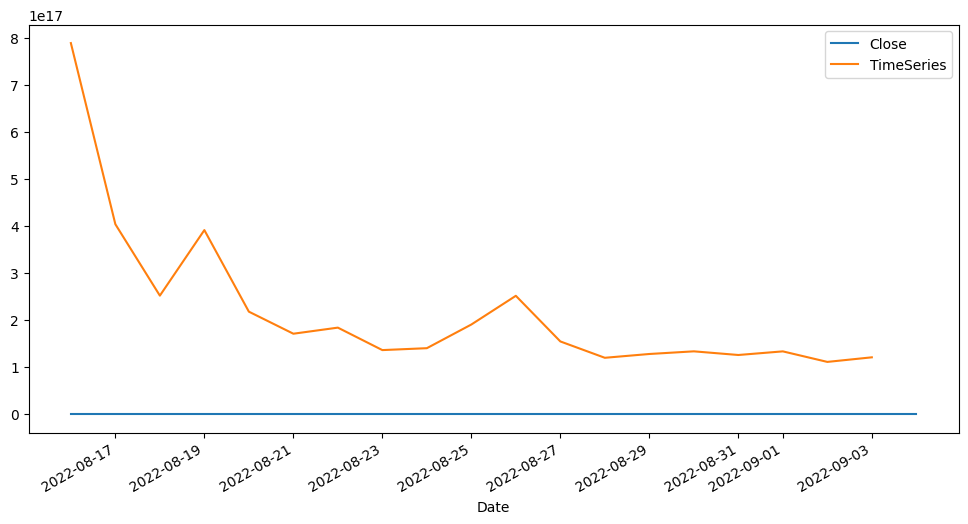

In [ ]:
test["Close"].plot(legend=True, figsize=(12, 6))
predictions.plot(label='TimeSeries', legend=True)

#### **CONCLUSION**
This project analyzes historical Dogecoin price data and applies a SARIMAX time-series forecasting model to predict future cryptocurrency prices. Feature engineering techniques were used to create volatility and volume-based indicators. Correlation analysis helped identify the most influential variables, and SARIMAX was trained using these features to generate forecasts. The final visualization compares actual and predicted values to evaluate model performance.


---


⚠️ Model is trained on only 11 records and tested on 19 records, which is very small for a forecasting model. For a stronger project, increase the training data size and evaluate using metrics such as MAE, RMSE, and R².

---




## **Corrections:**


In [ ]:
# Identify the full date range
full_date_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='D')

# Reindex the DataFrame to include all dates in the range
data = data.reindex(full_date_range)

# Forward-fill missing values, which is a common strategy for time series data
data = data.ffill()

# Verify that the missing date is now filled and check for any remaining NaNs
print(data.isnull().sum())
print(pd.date_range(data.index.min(), data.index.max(), freq='D').difference(data.index))

Close          0
Volume         0
gap            0
a              0
b              0
volume_lag1    0
dtype: int64
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


By reindexing and forward-filling, we ensure that our time series is continuous without gaps, which is important for models like SARIMAX. The output above confirms that there are no longer any missing dates or NaN values from this operation.

In [ ]:
data['volume_lag1'] = data['Volume'].shift(1)
# Only lagged Volume is retained as the exogenous variable.
# Redundant or unavailable variables were removed.
data = data.dropna()  # Drop the first row created by the lag feature

X = data[['volume_lag1']]
y = data['Close']

# Chronological 80/20 train-test split
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Scale exogenous variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame with original index and columns
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Build the SARIMAX model using the chosen ARIMA parameters
model = SARIMAX(y_train, exog=X_train_scaled_df, order=(5,1,4), freq='D')
fit = model.fit(maxiter=1000)

# No leakage: X_test only contains values that would genuinely
# have been available the day before each prediction
predictions = fit.forecast(steps=len(X_test), exog=X_test_scaled_df)

# Evaluate the forecasting performance
from sklearn.metrics import r2_score, mean_absolute_error
print("R²:", r2_score(y_test, predictions))
print("Mean Absolute Error(MAE):",mean_absolute_error(y_test, predictions))

R²: -2.570613650897484
Mean Absolute Error(MAE): 0.10522192956355564


In [ ]:
# Perform auto_arima to identify the optimal ARIMA (p, d, q) parameters
# We'll use the same exogenous variable X_train_scaled_df
# Stepwise=True makes the search faster by not trying all combinations
# trace=True will print the progress of the search

# Note: auto_arima by default searches for (p,d,q)(P,D,Q,s) for SARIMAX.
# Given your previous model was non-seasonal, I will set suppress_seasonal=True to focus on ARIMA parameters.
# You might want to adjust m (seasonal period) and suppress_seasonal based on domain knowledge.

print("Searching for optimal ARIMA parameters...")
stepwise_model = auto_arima(y_train, exog=X_train_scaled_df,
                            start_p=1, start_q=1,
                            max_p=5, max_q=5,
                            d=1, # Fixed d=1 as in your original model
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True,
                            seasonal=False) # Setting seasonal=False to search for ARIMA only

print("Optimal ARIMA parameters found:")
print(stepwise_model.summary())

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-8160.815, Time=0.66 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-8137.686, Time=0.38 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-8159.652, Time=0.74 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-8155.497, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-8139.457, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-8171.927, Time=1.14 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-8168.578, Time=0.69 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-8177.815, Time=0.54 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-8179.433, Time=0.32 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-8180.004, Time=1.69 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=-8280.168, Time=0.56 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=-8282.642, Time=0.63 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-8193.264, Time=1.66 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-8

This `auto_arima` search will identify the best `(p, d, q)` order for your SARIMAX model based on the AIC (Akaike Information Criterion) or BIC (Bayesian Information Criterion), which are used to evaluate model fit while penalizing complexity. Once the search is complete, you can use the recommended order to train your `SARIMAX` model.

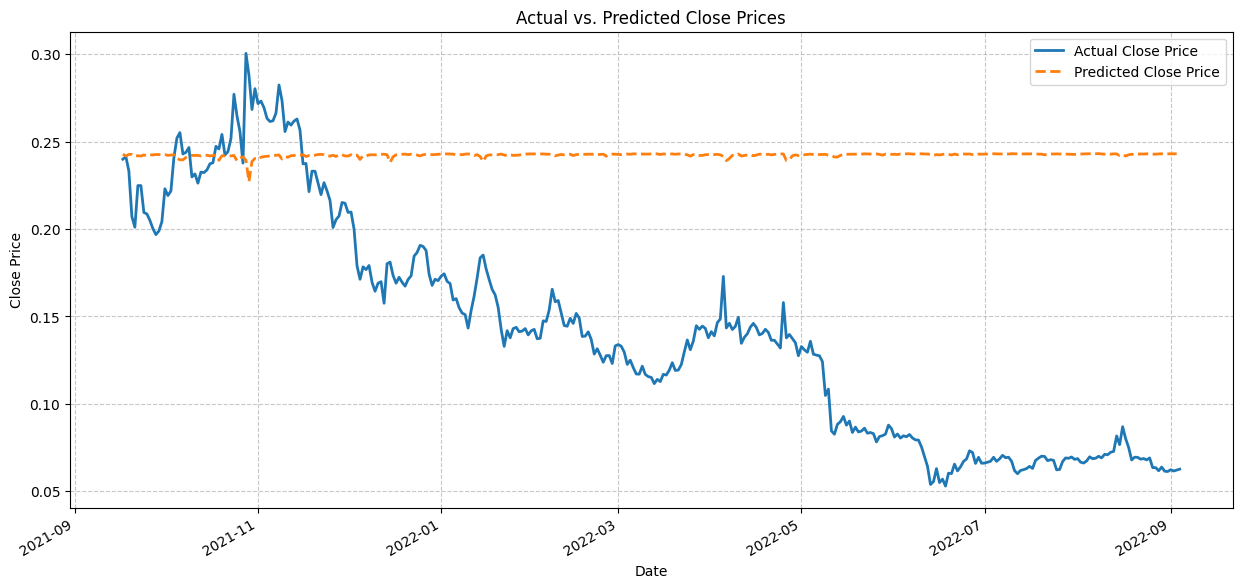

In [ ]:
plt.figure(figsize=(15, 7))
y_test.plot(label='Actual Close Price', legend=True, linewidth=2)
predictions.plot(label='Predicted Close Price', legend=True, linewidth=2, linestyle='--')
plt.title('Actual vs. Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### **Summary:**

The following improvements were made to enhance the reliability and correctness of the time-series forecasting model:

  - Missing dates were identified by reindexing the dataset to a complete  daily date range and forward-filling missing values to maintain continuity.
   - A lagged feature (volume_lag1) was introduced as the exogenous variable to ensure that only information available from the previous day was used, thereby preventing data leakage.
   - Redundant or unavailable variables were removed from the model to simplify the feature set.
   - A chronological 80/20 train-test split was applied to preserve the temporal order of the observations.
   - The exogenous variable was standardized using only the training data statistics, and the same transformation was applied to the test data to avoid information leakage.
   - A SARIMAX model was trained using the selected ARIMA order (5,1,4) with a daily frequency.
   - The auto_arima procedure was used to identify suitable ARIMA parameters for comparison and model selection.
    -Model performance was evaluated using the R² Score and Mean Absolute Error (MAE), and the predicted values were compared with the actual observations through visualization.

**Conclusion:**
These modifications improve the robustness of the forecasting pipeline by ensuring proper preprocessing, preventing data leakage, maintaining the chronological nature of the time series, and evaluating the model on unseen data using standard performance metrics.